# Lab 08: Functions and Tables


**Helpful Resource:**
- [Python Reference](http://data8.org/sp24/reference/): Cheat sheet of helpful array & table methods!

**Recommended Readings**:

* [Visualizing Numerical Distributions](https://www.inferentialthinking.com/chapters/07/2/Visualizing_Numerical_Distributions.html)
* [Functions and Tables](https://www.inferentialthinking.com/chapters/08/Functions_and_Tables.html)

Please complete this notebook by filling in the cells provided. **Before you begin, execute the cell below to setup the notebook by importing some helpful libraries.** Each time you start your server, you will need to execute this cell again.

In [1]:
!apt-get install texlive texlive-xetex texlive-latex-extra pandoc
!pip install pypandoc
!pip install datascience

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  dvisvgm fonts-droid-fallback fonts-lato fonts-lmodern fonts-noto-mono
  fonts-texgyre fonts-urw-base35 libapache-pom-java
  libcmark-gfm-extensions0.29.0.gfm.3 libcmark-gfm0.29.0.gfm.3
  libcommons-logging-java libcommons-parent-java libfontbox-java libgs9
  libgs9-common libidn12 libijs-0.35 libjbig2dec0 libkpathsea6 libpdfbox-java
  libptexenc1 libruby3.0 libsynctex2 libteckit0 libtexlua53 libtexluajit2
  libwoff1 libzzip-0-13 lmodern pandoc-data poppler-data preview-latex-style
  rake ruby ruby-net-telnet ruby-rubygems ruby-webrick ruby-xmlrpc ruby3.0
  rubygems-integration t1utils teckit tex-common tex-gyre texlive-base
  texlive-binaries texlive-fonts-recommended texlive-latex-base
  texlive-latex-recommended texlive-pictures texlive-plain-generic tipa
  xfonts-encodings xfonts-utils
Suggested packages:
  fonts-noto fonts-freefont-

In [2]:
# Connect Google Drive to Colab so you can access your files
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content/drive/MyDrive/Colab Notebooks/')

Mounted at /content/drive


In [37]:
# Run this cell to set up the notebook, but please don't change it.

# These lines import the Numpy and Datascience modules.
import numpy as np
from datascience import *

# These lines do some fancy plotting magic.
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

import warnings
warnings.simplefilter('ignore', FutureWarning)
warnings.filterwarnings("ignore")

## 1. Distribution of Durations



In [38]:
trip = Table.read_table('./DS/trip.csv')
trip.show(3)

Trip ID,Duration,Start Date,Start Station,Start Terminal,End Date,End Station,End Terminal,Bike #,Subscriber Type,Zip Code
913460,765,8/31/2015 23:26,Harry Bridges Plaza (Ferry Building),50,8/31/2015 23:39,San Francisco Caltrain (Townsend at 4th),70,288,Subscriber,2139
913459,1036,8/31/2015 23:11,San Antonio Shopping Center,31,8/31/2015 23:28,Mountain View City Hall,27,35,Subscriber,95032
913455,307,8/31/2015 23:13,Post at Kearny,47,8/31/2015 23:18,2nd at South Park,64,468,Subscriber,94107


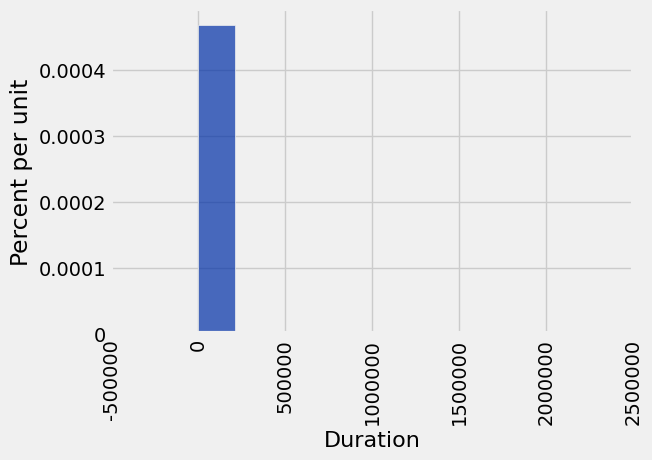

In [39]:
trip.hist('Duration')

In [40]:
trip.sort('Duration', descending=True)

Trip ID,Duration,Start Date,Start Station,Start Terminal,End Date,End Station,End Terminal,Bike #,Subscriber Type,Zip Code
825850,2137000,6/28/2015 21:50,Market at Sansome,77,7/23/2015 15:27,Yerba Buena Center of the Arts (3rd @ Howard),68,466,Customer,97213
750192,1852590,5/2/2015 6:17,San Antonio Shopping Center,31,5/23/2015 16:53,Castro Street and El Camino Real,32,680,Subscriber,94024
841176,1133540,7/10/2015 10:35,University and Emerson,35,7/23/2015 13:27,University and Emerson,35,262,Customer,94306
774999,688899,5/20/2015 15:27,Palo Alto Caltrain Station,34,5/28/2015 14:49,California Ave Caltrain Station,36,230,Customer,nil
635260,655939,2/8/2015 3:05,San Jose Civic Center,3,2/15/2015 17:17,SJSU 4th at San Carlos,12,132,Customer,89451
745640,611240,4/29/2015 9:41,University and Emerson,35,5/6/2015 11:28,San Antonio Shopping Center,31,196,Customer,81
635263,602338,2/8/2015 3:09,San Jose Civic Center,3,2/15/2015 2:28,San Jose Civic Center,3,9,Customer,89451
779645,594550,5/24/2015 13:33,San Pedro Square,6,5/31/2015 10:42,San Pedro Square,6,39,Customer,95118
812544,552697,6/18/2015 10:45,Mountain View Caltrain Station,28,6/24/2015 20:17,Palo Alto Caltrain Station,34,70,Customer,90024
661326,531240,2/27/2015 15:45,San Jose Diridon Caltrain Station,2,3/5/2015 19:19,SJSU 4th at San Carlos,12,662,Customer,95112


<br>

**Question 1.** Create histogram with bins ranging from 0 to 1800 in increments of 250

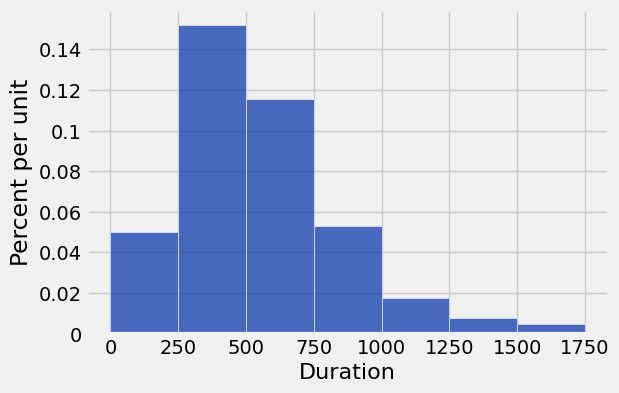

In [41]:
trip.hist('Duration', bins=np.arange(0, 1800, 250))

<br>

**Question 2.** Create histogram with more fine grained bins

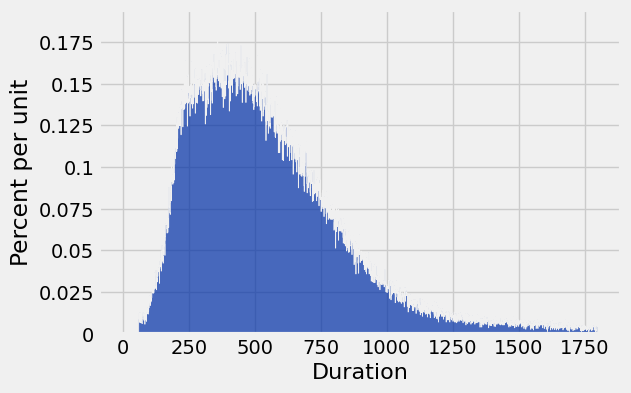

In [42]:
trip.hist('Duration', bins=np.arange(0, 1800))

## 2. Burrito-ful San Diego



Edwin, Gamy and Andrew are trying to use Data Science to find the best burritos in San Diego! Their friends Jessica, Aileen, and Conan provided them with two comprehensive datasets on many burrito establishments in the San Diego area taken and cleaned from [here](https://www.kaggle.com/srcole/burritos-in-san-diego/data)

The following cell reads in a table called `ratings` which contains names of burrito restaurants, their Yelp rating, Google rating, as well as their overall rating. The `Overall` rating is not an average of the `Yelp` and `Google` ratings, but rather it is the overall rating of the customers that were surveyed in the study above.


It also reads in a table called `burritos_types` which contains names of burrito restaurants, their menu items, and the cost of the respective menu item at the restaurant.

In [43]:
# Just run this cell
ratings = Table.read_table("./DS/ratings.csv")
ratings.show(5)
burritos_types = Table.read_table("./DS/burritos_types.csv").drop(0)
burritos_types.show(5)

Name,Yelp,Google,Overall
Albertacos,3.5,3.9,3.45
Burrito Factory,4.5,4.8,3.5
Burros and Fries,3.5,4.1,3.575
Caliente Mexican Food,3.5,4.4,3.25
California Burrito Company,3.5,4.4,3.2


Name,Menu_Item,Cost
Albertacos,California,5.7
Albertacos,Carne Asada,5.25
"Alberto's 623 N Escondido Blvd, Escondido, CA 92025",Carne Asada,4.59
Burrito Box,Steak With Guacamole,11.5
Burrito Factory,Steak Everything,7.35


**Question 1.** It would be easier if we could combine the information in both tables. Assign `burritos` to the result of joining the two tables together, so that we have a table with the ratings for every corresponding menu item from every restaurant. Each menu item has the same rating as the restaurant from which it is from. **(8 Points)**

*Hint:* Which function lets us combine information from two tables? Refer to the [Python Reference Sheet](http://data8.org/sp24/reference/) if you're unsure!


In [44]:
burritos = ratings.join('Name', burritos_types)
burritos.show(10)

Name,Yelp,Google,Overall,Menu_Item,Cost
Albertacos,3.5,3.9,3.45,California,5.7
Albertacos,3.5,3.9,3.45,Carne Asada,5.25
Burrito Factory,4.5,4.8,3.5,Steak Everything,7.35
Burros and Fries,3.5,4.1,3.575,California,7.19
Burros and Fries,3.5,4.1,3.575,Carne Asada,6.89
Burros and Fries,3.5,4.1,3.575,Shrimp California,6.99
Caliente Mexican Food,3.5,4.4,3.25,California,6.47
Caliente Mexican Food,3.5,4.4,3.25,Carne Asada,5.56
Caliente Mexican Food,3.5,4.4,3.25,Fried Fish,5.56
California Burrito Company,3.5,4.4,3.2,California,5.5


<!-- BEGIN QUESTION -->

**Question 2.** Let's look at how the Yelp scores compare to the Google scores in the `burritos` table. First, assign `yelp_google_tbl` to a table only containing the columns `Yelp` and `Google`. Then, make a scatter plot with Yelp scores on the x-axis and the Google scores on the y-axis. **(8 Points)**


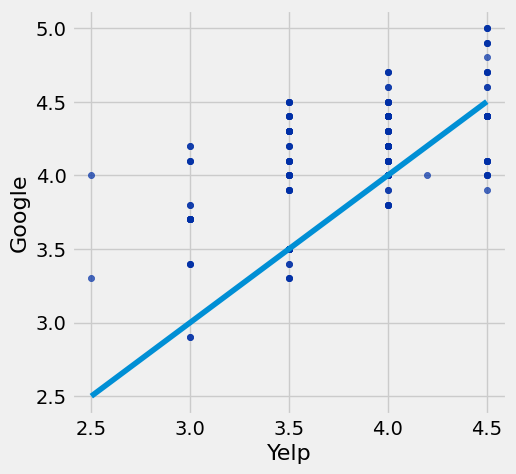

In [45]:
yelp_google_tbl = burritos.select('Yelp', 'Google')
yelp_google_tbl.scatter('Yelp', 'Google')

# Don't change/edit/remove the following line.
# To help you make conclusions, we have plotted a straight line on the graph (y=x).
plt.plot(np.arange(2.5,5,.5), np.arange(2.5,5,.5));

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

**Question 3.** Looking at the scatter plot you just made in Question 1.2, do you notice any pattern(s) or relationships between Yelp and Google ratings (i.e. is one of the two types of scores consistently higher than the other one)? If so, describe them **briefly** in the cell below. **(8 Points)**


Based on the scatter plot, we can see that there are more Google points than Yelp points, especially at scores above 4.0. Although there is a tendency for one rating to increase as the other increases, the high values of the Google ratings are mostly consistently above the y=x line.

<!-- END QUESTION -->

Here's a refresher on how `.group` works! You can read how `.group` works in the [textbook](https://www.inferentialthinking.com/chapters/08/2/Classifying_by_One_Variable.html).

**Question 4.** There are so many types of California burritos in the `burritos` table! Gamy wants to consider his options for burritos based on rankings. For the sake of these questions, we are treating each menu item's rating the same as its respective restaurant's, as we do not have the rating of every single item at these restaurants. You do not need to worry about this fact, but we thought to mention it!

Create a table with two columns: the first column include the **names of the burritos** and the second column should contain the **average overall rating** of that burrito across restaurants. **In your calculations, you should only compare burritos that contain the word "California".** For example, there are "California" burritos, "California Breakfast" burritos, "California Surf And Turf" burritos, etc. **(9 Points)**

*Hint:* “California” is case sensitive (“California” is not the same as “california”)!

*Note:* For reference, the staff solution only used one line. However, feel free to break up the solution into multiple lines and steps; just make sure you assign the final output table to `california_burritos`!


In [54]:
california_burritos = burritos.where("Menu_Item", are.containing("California")).group("Menu_Item", np.average).select("Menu_Item", "Overall average")
california_burritos

Menu_Item,Overall average
California,3.5242
California (Only Cheese),4.1
California + Guac + Sour Cream,3.4
California - Chicken,3.45839
California - Pork Adobada,3.26429
California - Steak,3.26429
California Breakfast,2.75833
California Chicken,3.54815
California Chipotle,4.36667
California Everything,4.1


**Question 5.** Given this new table `california_burritos`, Andrew can figure out the name of the California burrito with the highest overall average rating! Assign `best_california_burrito` to a line of code that outputs the string that represents the name of the California burrito with the highest overall average rating. If multiple burritos satisfy this criteria, you can output any one of them. **(8 Points)**


In [55]:
best_california_burrito = california_burritos.sort("Overall average", descending=True).column("Menu_Item").item(0)
best_california_burrito

'California Chipotle'

<!-- BEGIN QUESTION -->

**Question 6.** Edwin thinks that burritos in San Diego are cheaper (and taste better) than the burritos in Berkeley. Plot a histogram that visualizes that distribution of the costs of the burritos from San Diego in the `burritos` table. Also use the provided `cost_bins` variable when making your histogram, so that the histogram is more visually informative. **(8 Points)**


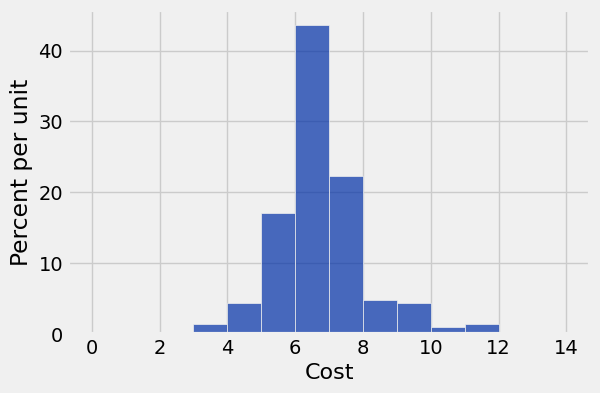

In [60]:
cost_bins = np.arange(0, 15, 1) # Do not change this line
# Please also use the provided bins
burritos.hist("Cost", bins=cost_bins)

<!-- END QUESTION -->

**Question 7.** What percentage of burritos in San Diego are less than $6? Assign `burritos_less_than_six` to your answer, **which should be between 0 and 100**. You should only use the histogram above to answer the question. Do not use code on the table to to find the answer, just eyeball the heights and use Python to evaluate your arithmetic! **(8 Points)**

*Note*: Your answer does not have to be exact, but it should be within a couple percentages of the staff answer.



In [65]:
burritos_less_than_six = 1 + 4 + 17

## Submission

Make sure you have run all cells in your notebook in order before running the cell below, so that all images/graphs appear in the output. The cell below will generate a pdf file for you to submit. **Please save before exporting!**

In [67]:
# should change the directory and file name matching to yours
!jupyter nbconvert './DS/lab08(SSU).ipynb' --to pdf

[NbConvertApp] Converting notebook ./DS/lab08(SSU).ipynb to pdf
[NbConvertApp] Support files will be in lab08(SSU)_files/
[NbConvertApp] Making directory ./lab08(SSU)_files
[NbConvertApp] Writing 74374 bytes to notebook.tex
[NbConvertApp] Building PDF
[NbConvertApp] Running xelatex 3 times: ['xelatex', 'notebook.tex', '-quiet']
[NbConvertApp] Running bibtex 1 time: ['bibtex', 'notebook']
[NbConvertApp] WARNING | bibtex had problems, most likely because there were no citations
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 186321 bytes to DS/lab08(SSU).pdf
